Importing Libraries

In [65]:
# Import necessary libraries

import requests
import numpy as np
import urllib.request
import json
import geocoder
import time
import geopy
import matplotlib.pyplot as plt

Fetching ISS (Two line element) TLE data

In [74]:

response = urllib.request.urlopen('http://api.open-notify.org/iss-now.json')
result = json.loads(response.read())
print(result)


{'timestamp': 1753381605, 'iss_position': {'longitude': '-153.1719', 'latitude': '-45.7994'}, 'message': 'success'}


In [76]:
from datetime import timedelta, datetime
from geopy.geocoders import Nominatim
import pytz
ist = pytz.timezone('Asia/Kolkata')

# Initialize Nominatim API
geolocator = Nominatim(user_agent="my_geopy_app")
name = str(input("Enter a location name: "))
location = geolocator.geocode(name)
print("\nLocation Coordinates:")
print(f"Latitude: {location.latitude}")
print(f"Longitude: {location.longitude}\n")


latitude, longitude = location.latitude, location.longitude
from skyfield.api import EarthSatellite, Topos, load

# TLE lines
line1 = '1 25544U 98067A   25204.16864096  .00010724  00000+0  19544-3 0  9992'
line2 = '2 25544  51.6344 128.7280 0002115 106.2807 253.8414 15.50025731520740'
satellite = EarthSatellite(line1, line2, 'ISS (ZARYA)')

# Load timescale and observer location
ts = load.timescale()
observer = Topos(latitude_degrees=latitude, longitude_degrees=longitude)
t0 = ts.now()
t1 = ts.utc(t0.utc_datetime() + timedelta(days=1))  # Next 24 hours

# Find events (rise, culmination, set)
times, events = satellite.find_events(observer, t0, t1, altitude_degrees=0.0) 

event_names = ['rise', 'culminate', 'set']
print("Next ISS Passes:\n")
group = []
for ti, event in zip(times, events):
    utc_dt = ti.utc_datetime().replace(tzinfo=pytz.utc)
    ist_dt = utc_dt.astimezone(ist)
    group.append(f"{event_names[event].capitalize()}: {ist_dt.strftime('%Y-%m-%d %H:%M:%S IST')}")
    if event == 2:  # 'set' event
        print("\n".join(group))
        print("-" * 40)
        group = []


Location Coordinates:
Latitude: 21.2380912
Longitude: 81.6336993

Next ISS Passes:

Rise: 2025-07-25 11:06:36 IST
Culminate: 2025-07-25 11:06:56 IST
Set: 2025-07-25 11:07:17 IST
----------------------------------------
Rise: 2025-07-25 12:37:46 IST
Culminate: 2025-07-25 12:43:09 IST
Set: 2025-07-25 12:48:32 IST
----------------------------------------
Rise: 2025-07-25 14:16:08 IST
Culminate: 2025-07-25 14:20:06 IST
Set: 2025-07-25 14:24:04 IST
----------------------------------------
Rise: 2025-07-25 20:52:22 IST
Culminate: 2025-07-25 20:56:19 IST
Set: 2025-07-25 21:00:16 IST
----------------------------------------
Rise: 2025-07-25 22:27:53 IST
Culminate: 2025-07-25 22:33:16 IST
Set: 2025-07-25 22:38:38 IST
----------------------------------------


In [20]:
from mpl_toolkits.basemap import Basemap

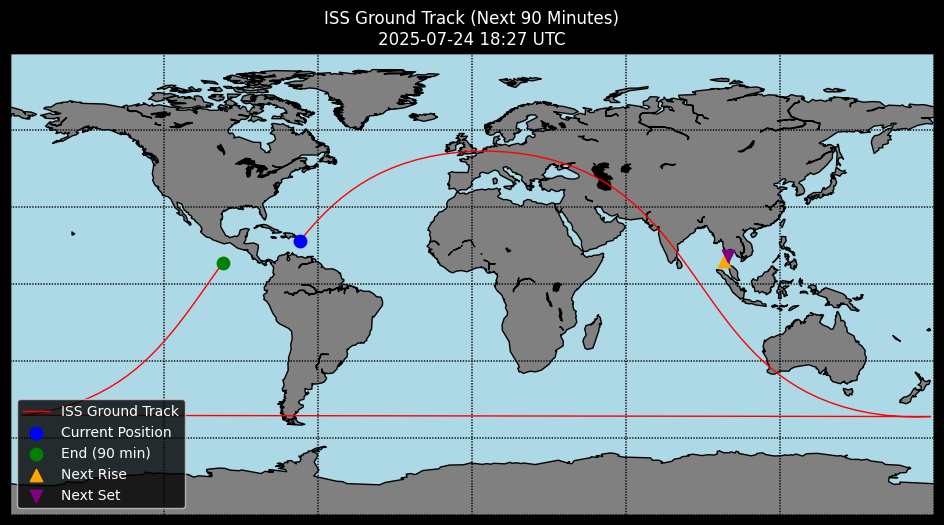

In [77]:

plt.figure(figsize=(12, 6))

m = Basemap(projection='cyl', llcrnrlat=-90, urcrnrlat=90,
            llcrnrlon=-180, urcrnrlon=180, resolution='c')
m.drawcoastlines()
m.fillcontinents(color='grey')
m.drawparallels(np.arange(-90., 91., 30.))
m.drawmeridians(np.arange(-180., 181., 60.))
m.drawmapboundary(fill_color='lightblue')

# ISS ground track
m.plot(lons, lats, color='red', linewidth=1, label='ISS Ground Track')

# Mark current position (first point)
m.scatter(lons[0], lats[0], color='blue', s=80, label='Current Position', zorder=5)

# Mark end position (last point)
m.scatter(lons[-1], lats[-1], color='green', s=80, label='End (90 min)', zorder=5)

# Mark next rise and set points if available
if 'times' in locals() and 'events' in locals():
    # Find next rise and set events
    rise_idx = None
    set_idx = None
    for idx, event in enumerate(events):
        if event == 0 and rise_idx is None:  # rise
            rise_idx = idx
        if event == 2 and set_idx is None:   # set
            set_idx = idx
    if rise_idx is not None:
        rise_time = times[rise_idx]
        rise_geocentric = satellite.at(rise_time)
        rise_subpoint = rise_geocentric.subpoint()
        m.scatter(rise_subpoint.longitude.degrees, rise_subpoint.latitude.degrees,
                  color='orange', s=80, marker='^', label='Next Rise', zorder=5)
    if set_idx is not None:
        set_time = times[set_idx]
        set_geocentric = satellite.at(set_time)
        set_subpoint = set_geocentric.subpoint()
        m.scatter(set_subpoint.longitude.degrees, set_subpoint.latitude.degrees,
                  color='purple', s=80, marker='v', label='Next Set', zorder=5)

# Title with current date/time
from datetime import datetime
plt.title(f"ISS Ground Track (Next 90 Minutes)\n{datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')}")
plt.legend(loc='lower left')
plt.show()

In [78]:
import pandas as pd

# Example CSV: locations.csv with columns: name,latitude,longitude
# name,latitude,longitude
#Delhi	28.7	77.1
#Raipur	21.25	81.62
#Ahmedabad	23.02	72.57
#Bhopal	23.25	77.41
#Nainital	29.39	79.45


df = pd.read_csv('locations.csv')
results = []

for idx, row in df.iterrows():
    observer = Topos(latitude_degrees=row['latitude'], longitude_degrees=row['longitude'])
    t0 = ts.now()
    t1 = ts.utc(t0.utc_datetime() + timedelta(days=1))
    times, events = satellite.find_events(observer, t0, t1, altitude_degrees=0.0)
    event_names = ['rise', 'culminate', 'set']
    group = {}
    for ti, event in zip(times, events):
        utc_dt = ti.utc_datetime().replace(tzinfo=pytz.utc)
        ist_dt = utc_dt.astimezone(ist)
        group[event_names[event]] = ist_dt.strftime('%Y-%m-%d %H:%M:%S IST')
        if event == 2:  # set
            results.append({
                'Location': row['name'],
                'Rise Time': group.get('rise', ''),
                'Culmination': group.get('culminate', ''),
                'Set Time': group.get('set', ''),
                'Duration (min)': (
                    pd.to_datetime(group.get('set', '')) - pd.to_datetime(group.get('rise', ''))
                ).total_seconds() / 60 if group.get('rise', '') and group.get('set', '') else ''
            })
            group = {}

results_df = pd.DataFrame(results)
print(results_df)
results_df.to_csv('iss_passes_results.csv', index=False)

     Location                Rise Time              Culmination  \
0       Delhi  2025-07-25 12:39:21 IST  2025-07-25 12:44:05 IST   
1       Delhi  2025-07-25 14:15:23 IST  2025-07-25 14:20:36 IST   
2       Delhi  2025-07-25 15:55:23 IST  2025-07-25 15:58:13 IST   
3       Delhi  2025-07-25 20:49:29 IST  2025-07-25 20:54:08 IST   
4       Delhi  2025-07-25 22:25:41 IST  2025-07-25 22:31:01 IST   
5      Raipur  2025-07-25 11:06:41 IST  2025-07-25 11:06:57 IST   
6      Raipur  2025-07-25 12:37:46 IST  2025-07-25 12:43:09 IST   
7      Raipur  2025-07-25 14:16:08 IST  2025-07-25 14:20:06 IST   
8      Raipur  2025-07-25 20:52:21 IST  2025-07-25 20:56:19 IST   
9      Raipur  2025-07-25 22:27:53 IST  2025-07-25 22:33:16 IST   
10  Ahmedabad  2025-07-25 00:54:04 IST  2025-07-25 00:56:05 IST   
11  Ahmedabad  2025-07-25 12:37:28 IST  2025-07-25 12:42:12 IST   
12  Ahmedabad  2025-07-25 14:13:38 IST  2025-07-25 14:18:44 IST   
13  Ahmedabad  2025-07-25 20:51:29 IST  2025-07-25 20:54:07 IS

C:\Users\asus\AppData\Local\Temp\ipykernel_11032\1760228499.py:33: FutureWarning: Parsed string "2025-07-25 12:48:50 IST" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  pd.to_datetime(group.get('set', '')) - pd.to_datetime(group.get('rise', ''))
C:\Users\asus\AppData\Local\Temp\ipykernel_11032\1760228499.py:33: FutureWarning: Parsed string "2025-07-25 12:39:21 IST" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  pd.to_datetime(group.get('set', '')) - pd.to_datetime(group.get('rise', ''))
C:\Users\asus\AppData\Local\Temp\ipykernel_11032\1760228499.py:33: FutureWarning: Parsed string "2025-07-25 14:25:50 IST" included an un